In [143]:
import pandas as pd 

data = pd.read_csv('Live.csv')
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [144]:
data = data.drop(columns=["Column1", "Column2", "Column3", "Column4", "status_id", "status_published"])
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB
None


In [145]:
#vemos que solo hay una variable categorica
from sklearn.preprocessing import LabelEncoder

#hacemos el label encoder
le = LabelEncoder()
data['status_type_encoded'] = le.fit_transform(data['status_type'])
data[['status_type', 'status_type_encoded']].head()

#eliminamos la variable categorica
data = data.drop(columns='status_type')

In [146]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#escalamos
data_scaled = scaler.fit_transform(data)

#volvemos la info a dataframe
cols = data.columns
data_scaled = pd.DataFrame(data_scaled, columns=cols)

#vemos el resultado
data_scaled.head()


,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_encoded
0,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0,1.000000
1,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0,0.333333
2,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0,1.000000
3,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0,0.333333
4,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0,0.333333


In [147]:
from sklearn.cluster import KMeans

#hacemos kmeans con 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(data_scaled)

#añadimos los clusters al datafreme
data_scaled['cluster'] = kmeans.labels_

#vemos las primeras filas
data_scaled.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_encoded,cluster
0,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0,1.000000,1
1,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0,0.333333,0
2,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0,1.000000,1
3,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0,0.333333,0
4,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0,0.333333,0


In [148]:
#para la inercia
inertia = kmeans.inertia_
print(inertia)

'''La inercia corresponde a la suma de las distancias al cuadrado entre cada punto y su centroide asignado. Entre más baja, mejor agrupados están los datos 
y si es muy alta, significa que los puntos están muy dispersos dentro de los clusters.'''

240.06686397262814


'La inercia corresponde a la suma de las distancias al cuadrado entre cada punto y su centroide asignado. Entre más baja, mejor agrupados están los datos \ny si es muy alta, significa que los puntos están muy dispersos dentro de los clusters.'

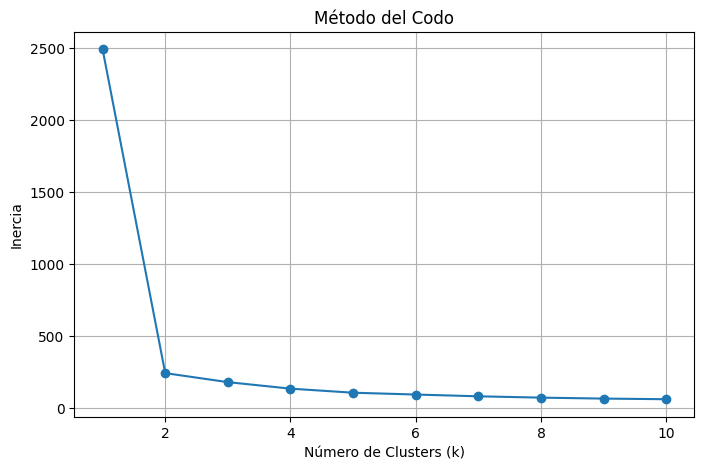

In [149]:
import matplotlib.pyplot as plt

#vamos a hacer un recorrido con distintos valores de k
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertias.append(kmeans.inertia_)

#para la grafica
plt.figure(figsize=(8, 5))
plt.plot(K, inertias, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()


In [150]:
'''Vemos que en efecto 2 es el numero optimo de clusters'''

#con k = 3
kmeans3 = KMeans(n_clusters=3, random_state=42)
kmeans3.fit(data_scaled)
inertia3 = kmeans3.inertia_

#con k = 4
kmeans4 = KMeans(n_clusters=4, random_state=42)
kmeans4.fit(data_scaled)
inertia4 = kmeans4.inertia_

print(inertia3, inertia4)

'''Vemos que a pesar de que la grafica no lo hace tan evidente, en k=4 hay una disminucion considerable de la inercia, ademas una clusterizacion con k=2 seria muy simple. Por lo tanto
podemos considerar que k=4 es el numero de clusters optimo.'''

177.3182524048648 132.06160251229738


'Vemos que a pesar de que la grafica no lo hace tan evidente, en k=4 hay una disminucion considerable de la inercia, ademas una clusterizacion con k=2 seria muy simple. Por lo tanto\npodemos considerar que k=4 es el numero de clusters optimo.'

In [151]:
#entonces nos quedamos con 4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data_scaled)

#reescribimos columna con los clusters = 4
data_scaled['cluster'] = kmeans.labels_

In [152]:
from sklearn.decomposition import PCA

#definimos y metemos los datos para 2 componentes prencipales
pca = PCA(n_components=2)
pca_components = pca.fit_transform(data_scaled.drop(columns='cluster'))

#lo convertimos a dataframe
pca_data = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

#agregamos los clusters hechos con anterioridad
pca_data['cluster'] = data_scaled['cluster']


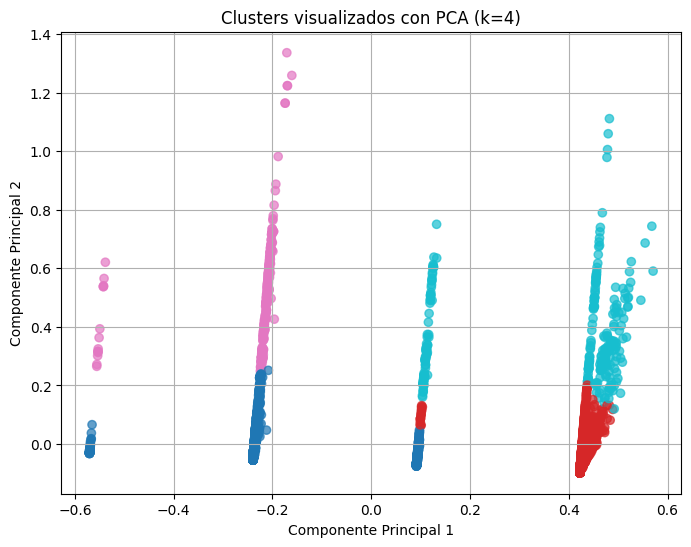

In [153]:
#por ultimo graficamos

plt.figure(figsize=(8,6))
plt.scatter(
    pca_data['PC1'],
    pca_data['PC2'],
    c=pca_data['cluster'],
    cmap='tab10',
    alpha=0.7
)

plt.title('Clusters visualizados con PCA (k=4)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()
